In [3]:
import os
import sys
import yaml
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

if os.path.basename(os.getcwd()) != 'audio_event_detection':
    os.chdir('..')
from models.ast_model import AudioSpectrogramTransformer
from scripts.train import Trainer
 
from scripts.evaluate import ModelEvaluator
from utils.dataset import AudioEventDataset

In [4]:
# Load tập test
config_path = 'configs/config.yaml'
metadata_df = pd.read_csv('data/processed/spectrograms/processed_metadata.csv')
train_df, temp_df = train_test_split(metadata_df, test_size=0.2, random_state=42, stratify=metadata_df['label'])

with open(config_path, 'r') as f:
    config_dict = yaml.safe_load(f)
batch_size = config_dict['training']['batch_size']
num_workers = config_dict.get('hardware', {}).get('num_workers', 4)
pin_memory = config_dict.get('hardware', {}).get('pin_memory', True)

val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])
test_dataset = AudioEventDataset(test_df, config_path, mode='test')
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, 
                         num_workers=num_workers, pin_memory=pin_memory)


In [5]:
best_model_path = os.path.join(os.getcwd(), config_dict['paths']['checkpoint_dir'], 'best_model.pth')
Evaluator = ModelEvaluator(
    model_path=best_model_path
)

Evaluator initialized on cpu


In [7]:
results = Evaluator.evaluate(test_loader)


Evaluating model...


Evaluation: 100%|██████████| 34/34 [03:54<00:00,  6.89s/it]


In [ ]:
Evaluator.save_results(results, output_path="results/evaluation_results.json")
Evaluator.plot_results(results, output_dir="results/plots")



Results saved to results/evaluation_results.json

Generating visualizations...
  - Confusion matrix...
Confusion matrix saved to results/plots\confusion_matrix.png
  - Per-class metrics...
  - ROC curves...
  - Precision-Recall curves...

Plots saved to results/plots


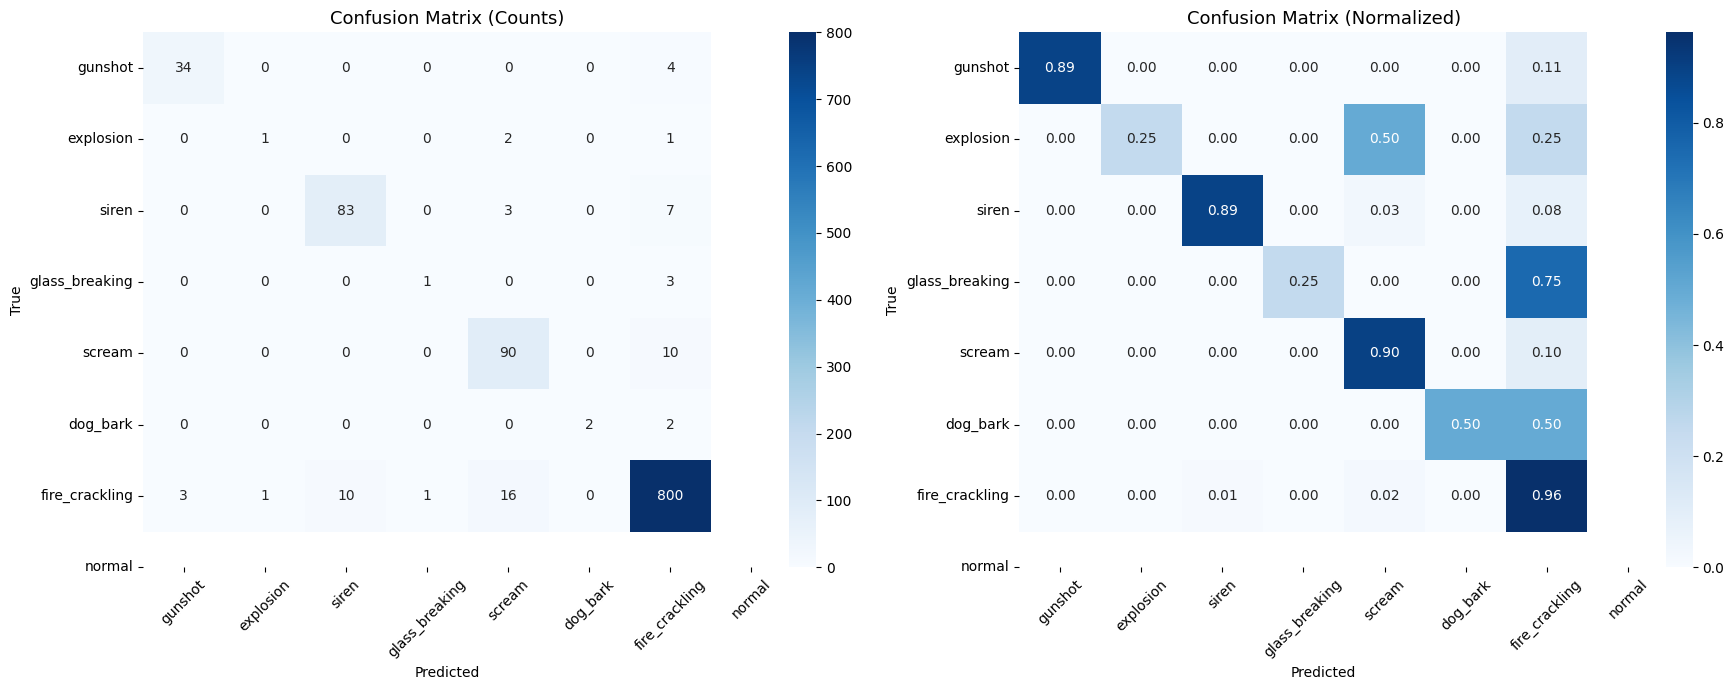

In [16]:
# ── 1. Confusion Matrix ──────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = results['confusion_matrix']
class_names = Evaluator.class_names
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

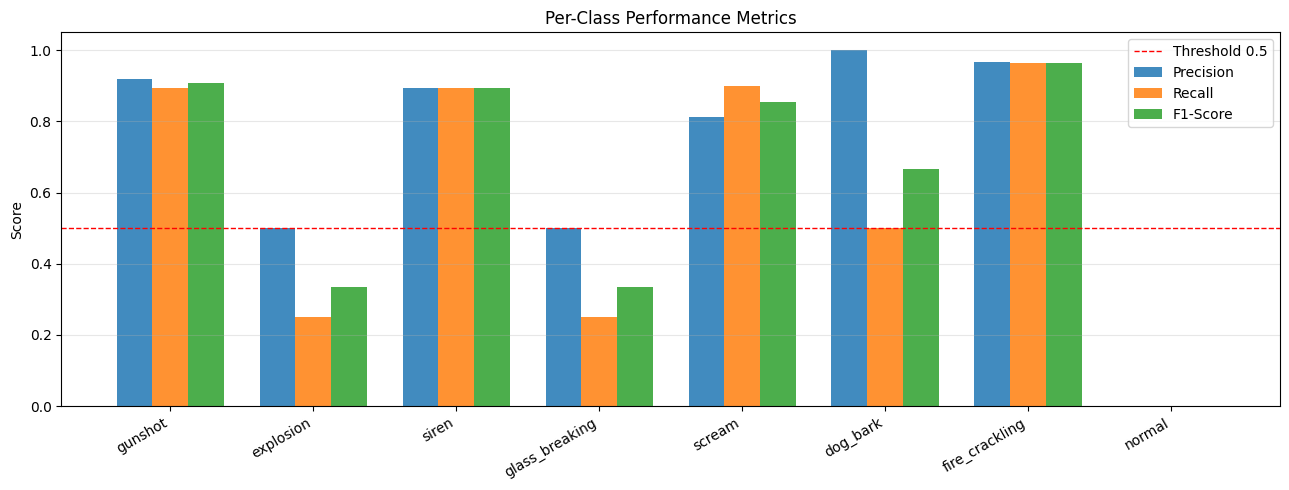

In [17]:
# ── 2. Per-class Metrics ─────────────────────────────────────
metrics = results['metrics']

precision = [metrics.get(f'precision_{c}', 0) for c in class_names]
recall    = [metrics.get(f'recall_{c}', 0)    for c in class_names]
f1        = [metrics.get(f'f1_{c}', 0)        for c in class_names]

x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width, precision, width, label='Precision', alpha=0.85)
ax.bar(x,         recall,    width, label='Recall',    alpha=0.85)
ax.bar(x + width, f1,        width, label='F1-Score',  alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_ylabel('Score')
ax.set_title('Per-Class Performance Metrics')
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Threshold 0.5')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

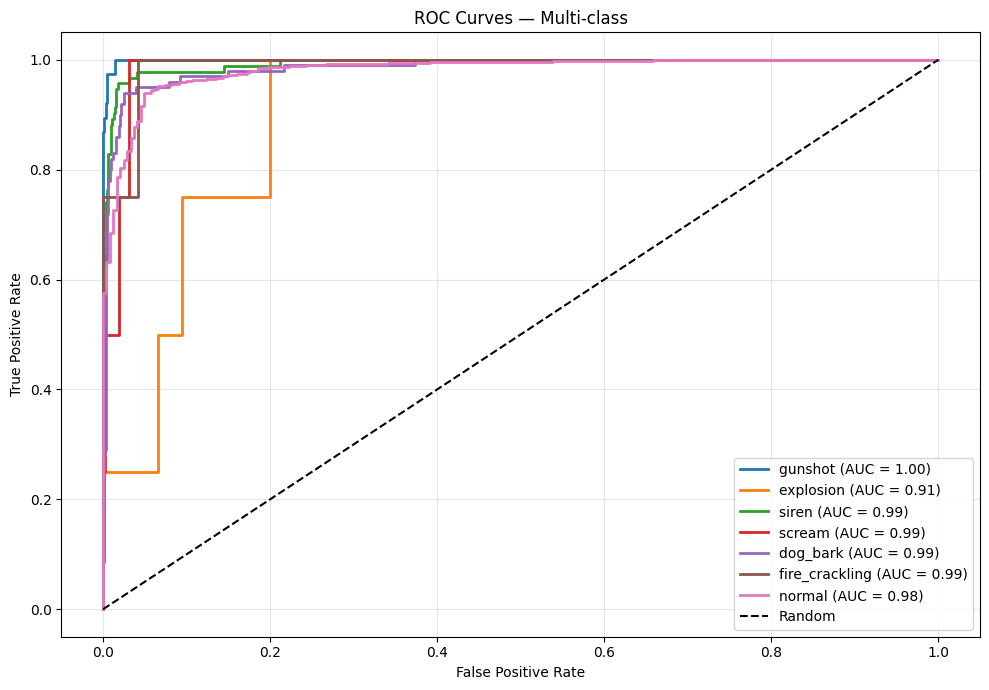

In [18]:
# ── 3. ROC Curves ────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true = results['predictions']['y_true']
y_prob = results['predictions']['y_prob']
n_classes = len(class_names)

y_true_bin = label_binarize(y_true, classes=range(n_classes))

fig, ax = plt.subplots(figsize=(10, 7))
for i, name in enumerate(class_names):
    if y_true_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Multi-class')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

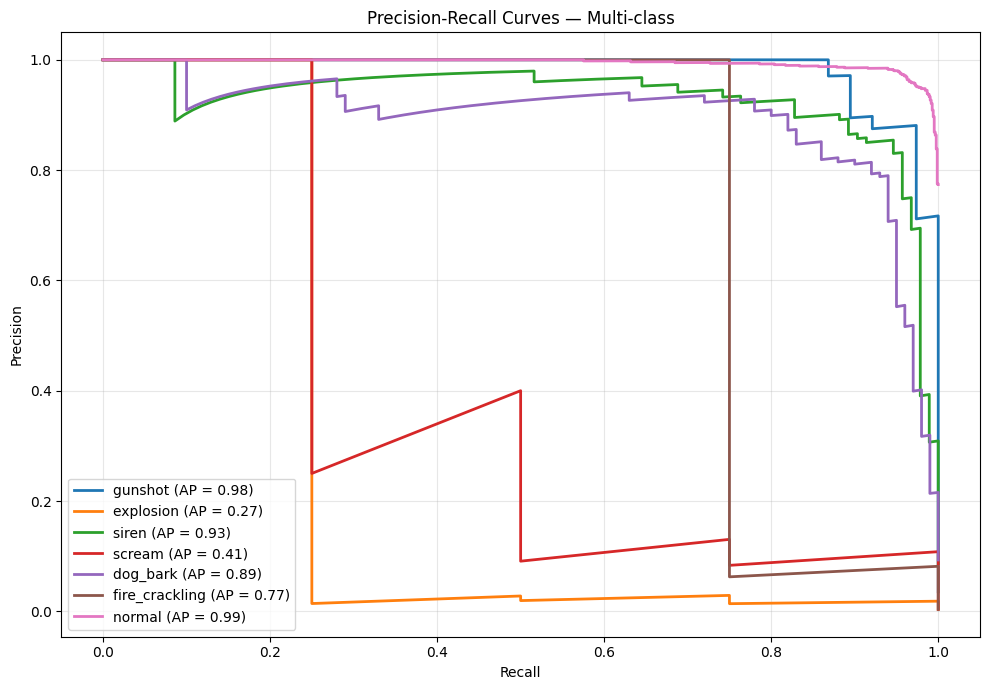

In [19]:
# ── 4. Precision-Recall Curves ───────────────────────────────
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(10, 7))
for i, name in enumerate(class_names):
    if y_true_bin[:, i].sum() == 0:
        continue
    prec, rec, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_prob[:, i])
    ax.plot(rec, prec, lw=2, label=f'{name} (AP = {ap:.2f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — Multi-class')
ax.legend(loc='lower left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
metrics = results['metrics']

print("=" * 50)
print("        RESULTS SUMMARY")
print("=" * 50)
print(f"  Accuracy       : {metrics['accuracy']:.4f}  ({metrics['accuracy']*100:.2f}%)")
print(f"  Precision      : {metrics['precision']:.4f}")
print(f"  Recall         : {metrics['recall']:.4f}")
print(f"  F1-Score       : {metrics['f1_score']:.4f}")
print(f"  mAP            : {metrics['map']:.4f}")
print("=" * 50)

        KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH
  Accuracy       : 0.9413  (94.13%)
  Precision      : 0.7985
  Recall         : 0.6643
  F1-Score       : 0.7072
  mAP            : 0.6564


In [ ]:
import pandas as pd

class_names = Evaluator.class_names
per_class_data = []

for name in class_names:
    per_class_data.append({
        'Class'     : name,
        'Precision' : metrics.get(f'precision_{name}', 0),
        'Recall'    : metrics.get(f'recall_{name}', 0),
        'F1-Score'  : metrics.get(f'f1_{name}', 0),
    })

df_per_class = pd.DataFrame(per_class_data).set_index('Class')
df_per_class = df_per_class.sort_values('F1-Score', ascending=False)

print("\nPer-class Performance (sorted by F1):")
print(df_per_class.to_string(float_format='{:.4f}'.format))

weak_classes = df_per_class[df_per_class['F1-Score'] < 0.5]
if not weak_classes.empty:
    print(f"\n  Class need to be improved (F1 < 0.5): {list(weak_classes.index)}")


Per-class Performance (sorted by F1):
                Precision  Recall  F1-Score
Class                                      
fire_crackling     0.9674  0.9627    0.9650
gunshot            0.9189  0.8947    0.9067
siren              0.8925  0.8925    0.8925
scream             0.8108  0.9000    0.8531
dog_bark           1.0000  0.5000    0.6667
explosion          0.5000  0.2500    0.3333
glass_breaking     0.5000  0.2500    0.3333
normal             0.0000  0.0000    0.0000

  Class need to be improved (F1 < 0.5): ['explosion', 'glass_breaking', 'normal']


In [ ]:
print("\nClassification Report:")
print(results['classification_report'])


Classification Report:
                precision    recall  f1-score   support

       gunshot       0.92      0.89      0.91        38
     explosion       0.50      0.25      0.33         4
         siren       0.89      0.89      0.89        93
glass_breaking       0.00      0.00      0.00         0
        scream       0.50      0.25      0.33         4
      dog_bark       0.81      0.90      0.85       100
fire_crackling       1.00      0.50      0.67         4
        normal       0.97      0.96      0.97       831

      accuracy                           0.94      1074
     macro avg       0.70      0.58      0.62      1074
  weighted avg       0.94      0.94      0.94      1074

